# 🚀 Étape 1 : Exploration des Données (EDA)
**Objectif :** Comprendre la structure de nos données Rocket League et identifier les "signaux faibles" (features) qui différencient le comportement d'un joueur légitime (Diamant) d'un joueur élite (Grand Champion).

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Chargement des données brutes
# (On remonte d'un dossier pour aller chercher dans data/)
df = pd.read_csv('../data/rocket_league_skill_data.csv')

print(f"Dimension du dataset : {df.shape[0]} joueurs et {df.shape[1]} variables.")
print("\nAperçu des données :")
display(df.head())

Dimension du dataset : 3599 joueurs et 62 variables.

Aperçu des données :


,shooting percentage,bpm,avg boost amount,amount collected,amount collected big pads,amount collected small pads,count collected big pads,count collected small pads,amount stolen,amount stolen big pads,...,percentage neutral third,time offensive third,percentage offensive third,avg distance to ball,avg distance to ball has possession,avg distance to ball no possession,avg distance to team mates,demos inflicted,demos taken,Target
0,20.00,404,45.78,2435,1574,861,19,76,848,531,...,34.08,71.30,19.86,2338,2090,2520,2986,1,1,1
1,33.33,446,42.77,2390,1550,840,18,75,448,117,...,30.64,75.92,21.53,2047,1894,2191,2826,0,0,1
2,57.14,451,43.42,2450,1948,502,21,43,421,300,...,27.87,93.95,24.90,2415,2324,2549,3805,1,1,0
3,50.00,465,52.11,2780,2201,579,24,53,519,253,...,27.14,82.64,22.27,2328,2148,2537,3338,1,2,0
4,25.00,453,46.93,2233,1688,545,19,50,788,543,...,30.31,95.04,31.80,2134,2048,2249,2985,1,0,1


### 📊 1. Analyse de la Répartition des Classes
Vérifions si notre jeu de données est équilibré.

Target
1    50.013893
0    49.986107
Name: proportion, dtype: float64


/var/folders/1n/sp27yb_j1_jf0wx6b_g2lqz80000gn/T/ipykernel_92680/4212514485.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Target', data=df, palette=['skyblue', 'red'])


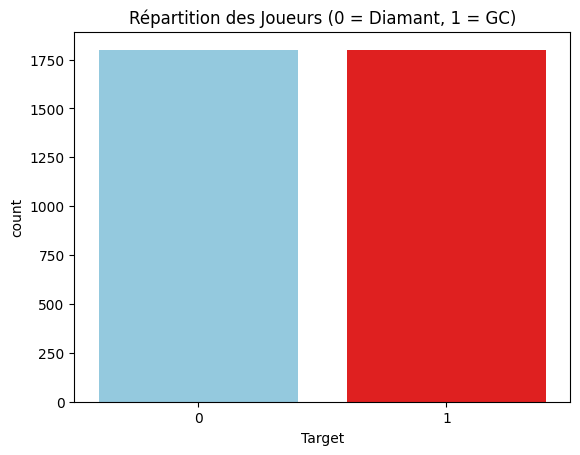

In [2]:
# Vérification de la cible (0 = Diamond, 1 = GC)
repartition = df['Target'].value_counts(normalize=True) * 100
print(repartition)

sns.countplot(x='Target', data=df, palette=['skyblue', 'red'])
plt.title("Répartition des Joueurs (0 = Diamant, 1 = GC)")
plt.show()

### 🏎️ 2. La "Signature" du Smurf
L'hypothèse métier est qu'un Smurf (GC) se déplace beaucoup plus vite et gère mieux son boost. Isolons la variable `percentage supersonic speed` pour le vérifier visuellement.

Médiane Vitesse Diamond : 11.2%
Médiane Vitesse GC      : 16.7%


/var/folders/1n/sp27yb_j1_jf0wx6b_g2lqz80000gn/T/ipykernel_92680/2004605341.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


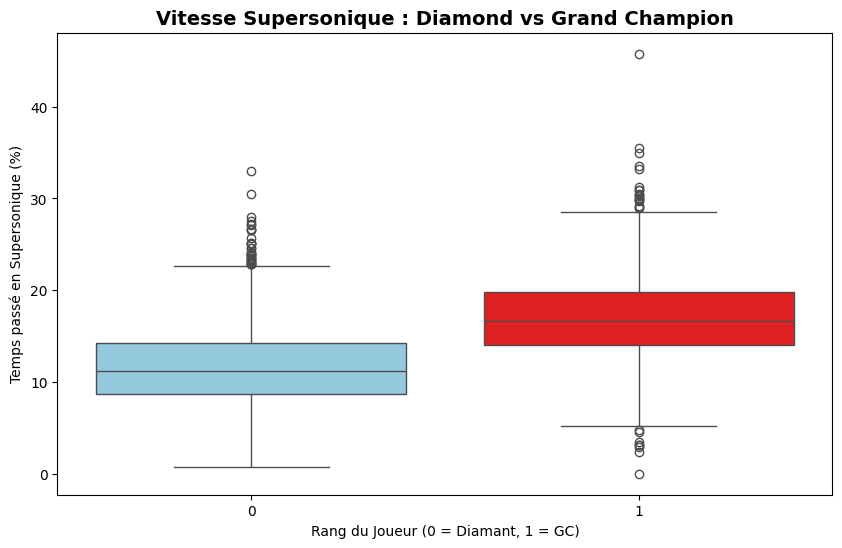

In [3]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    x='Target', 
    y='percentage supersonic speed', 
    data=df, 
    palette=['skyblue', 'red']
)
plt.title('Vitesse Supersonique : Diamond vs Grand Champion', fontsize=14, fontweight='bold')
plt.xlabel('Rang du Joueur (0 = Diamant, 1 = GC)')
plt.ylabel('Temps passé en Supersonique (%)')

# Calcul des médianes pour appuyer le propos
median_diamond = df[df['Target'] == 0]['percentage supersonic speed'].median()
median_gc = df[df['Target'] == 1]['percentage supersonic speed'].median()

print(f"Médiane Vitesse Diamond : {median_diamond:.1f}%")
print(f"Médiane Vitesse GC      : {median_gc:.1f}%")

plt.show()

**Conclusion de l'exploration :**
Le dataset est parfaitement équilibré (50/50). L'analyse exploratoire confirme notre intuition métier : les joueurs de haut niveau ont un comportement physique distinct (ils passent en moyenne 6% de temps en plus à vitesse supersonique). Cela valide la pertinence de passer à l'étape du Machine Learning pour détecter ces anomalies.